# FAPE, FairGround Corpus EDA
## Multi-Domain Benchmark Analysis

**Corpus:** FairGround, Fabris et al. (2025)  
**Datasets loaded:** 37 of 38 (1 failed, law_school_tensorflow HTTP 403)  
**Total records:** 1,964,010  
**Domains:** Criminal justice, financial, healthcare, education, socioeconomic, other/synthetic  

FairGround addresses the benchmark monoculture problem identified by Ding et al. (2021), pre-validated sensitive attribute metadata eliminates arbitrary preprocessing choices.

In [1]:
import sys
import os
sys.path.insert(0, '../src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from fairground_loader import load_fairground_corpus

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

os.makedirs('../figures/eda', exist_ok=True)
print('Imports complete')

Imports complete


In [2]:
corpus = load_fairground_corpus()

def get_domain(name):
    if any(x in name for x in ['compas','stop_question','chicago','ricci']):
        return 'Criminal Justice'
    elif any(x in name for x in ['credit','bank']):
        return 'Financial'
    elif any(x in name for x in ['meps','heart','arrhythmia']):
        return 'Healthcare'
    elif any(x in name for x in ['student','law_school','nursery']):
        return 'Education'
    elif any(x in name for x in ['adult','folktables','dutch','communities']):
        return 'Socioeconomic'
    else:
        return 'Other/Synthetic'

def get_balance(rate):
    if rate is None or pd.isna(rate):
        return 'No rate computed'
    elif rate < 0 or rate > 1:
        return 'Non-binary target'
    elif 0.3 <= rate <= 0.7:
        return 'Balanced (30-70%)'
    else:
        return 'Imbalanced'

rows = []
for k, v in corpus.items():
    meta = v['metadata']
    rows.append({
        'dataset': k,
        'n_samples': meta['n_samples'],
        'n_features': meta['n_features'],
        'sensitive_cols': meta['sensitive_columns'],
        'positive_rate': meta['positive_rate'],
        'domain': get_domain(k),
        'balance': get_balance(meta['positive_rate'])
    })
df = pd.DataFrame(rows)

DOMAIN_ORDER = ['Criminal Justice','Financial','Healthcare','Education','Socioeconomic','Other/Synthetic']
DOMAIN_COLORS = dict(zip(DOMAIN_ORDER, sns.color_palette('muted', 6)))

print(f'Datasets: {len(df)} | Total records: {df["n_samples"].sum():,}')
print(df['domain'].value_counts())

FairGround corpus: 38 datasets available


[14:45:37] INFO     Loading cached dataset from cache/datasets/adult.parquet                         ]8;id=748276;file:///Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/fairml_datasets/dataset.py\dataset.py]8;;\:]8;id=564656;file:///Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/fairml_datasets/dataset.py#250\250]8;;\

           INFO     Loading cached dataset from cache/datasets/adult.parquet                         ]8;id=681756;file:///Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/fairml_datasets/dataset.py\dataset.py]8;;\:]8;id=732509;file:///Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/fairml_datasets/dataset.py#250\250]8;;\

  OK: adult: 32,560 rows | 14 features | sensitive: ['race']


           INFO     Loading cached dataset from cache/datasets/arrhythmia.parquet                    ]8;id=209993;file:///Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/fairml_datasets/dataset.py\dataset.py]8;;\:]8;id=59258;file:///Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/fairml_datasets/dataset.py#250\250]8;;\

...

           INFO     Loading cached dataset from                                                      ]8;id=297038;file:///Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/fairml_datasets/dataset.py\dataset.py]8;;\:]8;id=934181;file:///Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/fairml_datasets/dataset.py#250\250]8;;\
                    cache/datasets/folktables_acsemployment_small.parquet                                          

  OK: folktables_acsemployment_small: 478,236 rows | 16 features | sensitive: ['RAC1P']


           INFO     Loading cached dataset from                                                      ]8;id=390878;file:///Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/fairml_datasets/dataset.py\dataset.py]8;;\:]8;id=173867;file:///Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/fairml_datasets/dataset.py#250\250]8;;\
                    cache/datasets/folktables_acstraveltime_small.parquet                                          

           INFO     Loading cached dataset from                                                      ]8;id=648754;file:///Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/fairml_datasets/dataset.py\dataset.py]8;;\:]8;id=519833;file:///Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/fairml_datasets/dataset.py#250\250]8;;\
                    cache/datasets/folktables_acstraveltime_small.parquet                                          

  OK: folktables_acstraveltime_small: 216,385 rows | 16 features | sensitive: ['RAC1P']

FairGround load complete:
  Loaded:  36 datasets
  Failed:  2 datasets
  Records: 1,955,063 total

Failed datasets:
  law_school_tensorflow: HTTP Error 403: Forbidden
  stop_question_and_frisk_data: HTTP Error 403: Forbidden
Datasets: 36 | Total records: 1,955,063
domain
Socioeconomic       9
Financial           9
Healthcare          5
Criminal Justice    5
Other/Synthetic     4
Education           4
Name: count, dtype: int64


## 1. Dataset Sizes, All 37 Datasets

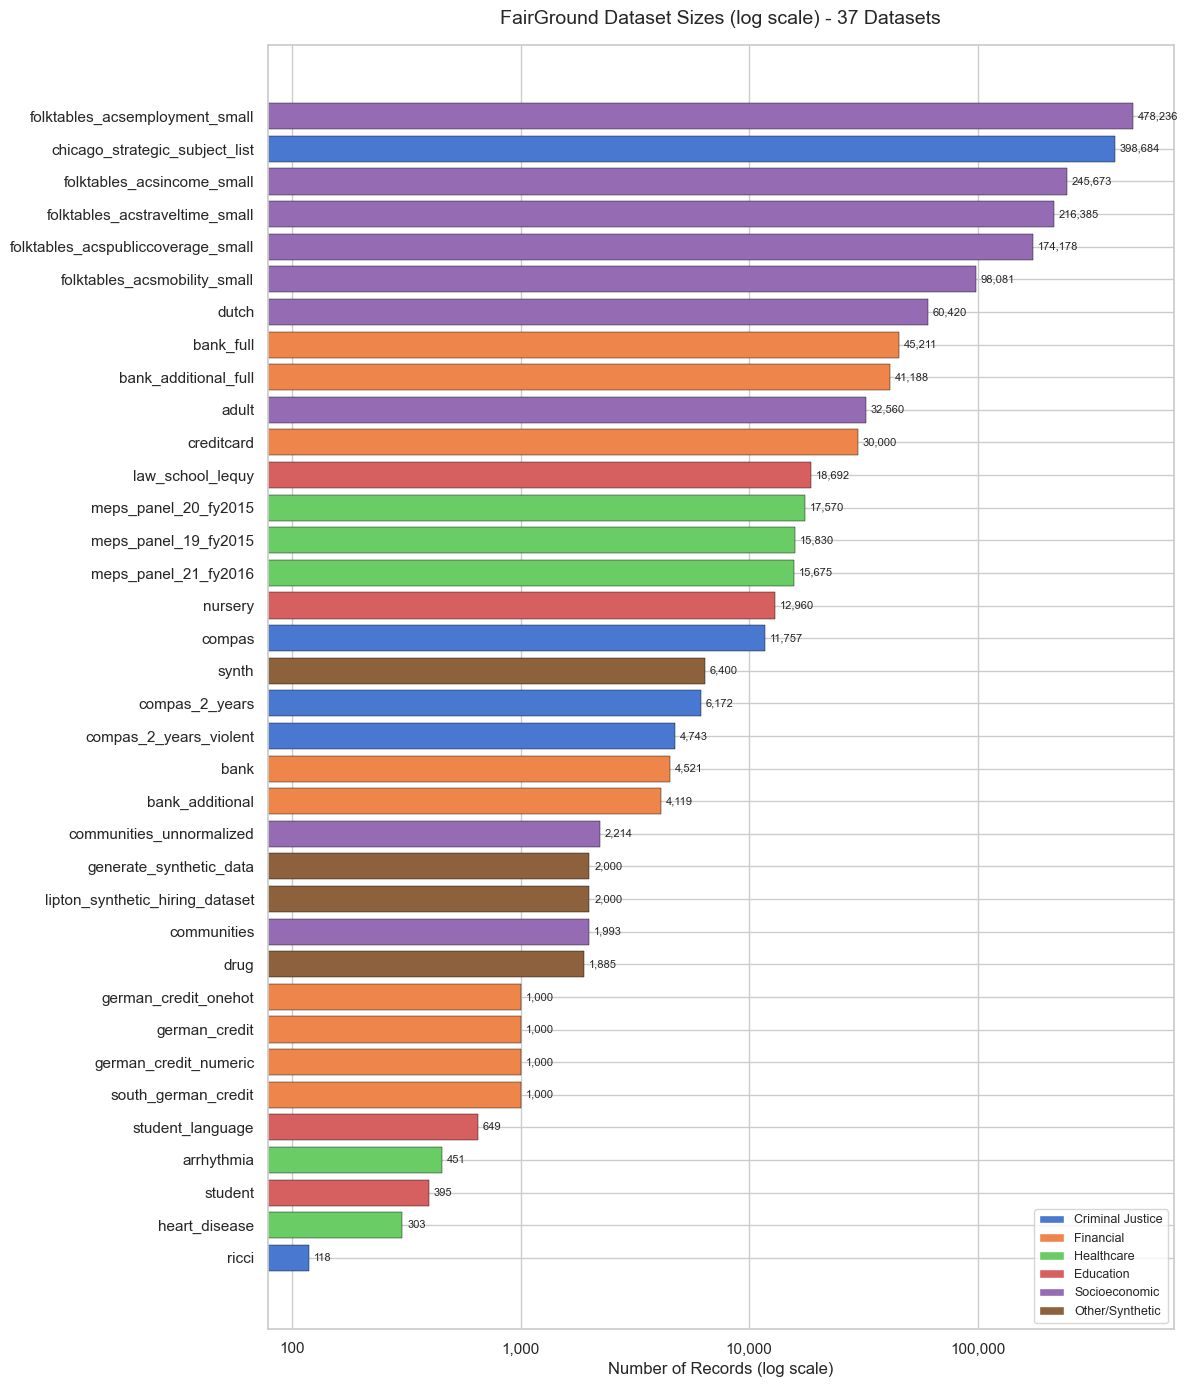

Largest: folktables_acsemployment_small, 478,236
Smallest: ricci, 118
Median: 6,286


In [3]:
df_sorted = df.sort_values('n_samples', ascending=True)

fig, ax = plt.subplots(figsize=(12, 14))
colors = [DOMAIN_COLORS[d] for d in df_sorted['domain']]
bars = ax.barh(df_sorted['dataset'], df_sorted['n_samples'],
               color=colors, edgecolor='black', linewidth=0.3)
ax.set_xscale('log')
ax.set_title('FairGround Dataset Sizes (log scale) - 37 Datasets', fontsize=14, pad=15)
ax.set_xlabel('Number of Records (log scale)')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{int(x):,}'))
for bar, val in zip(bars, df_sorted['n_samples']):
    ax.text(bar.get_width() * 1.05, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=8)
# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=DOMAIN_COLORS[d], label=d) for d in DOMAIN_ORDER]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('../figures/eda/fairground_dataset_sizes.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Largest: {df.loc[df["n_samples"].idxmax(), "dataset"]}, {df["n_samples"].max():,}')
print(f'Smallest: {df.loc[df["n_samples"].idxmin(), "dataset"]}, {df["n_samples"].min():,}')
print(f'Median: {df["n_samples"].median():,.0f}')

## 2. Domain Coverage

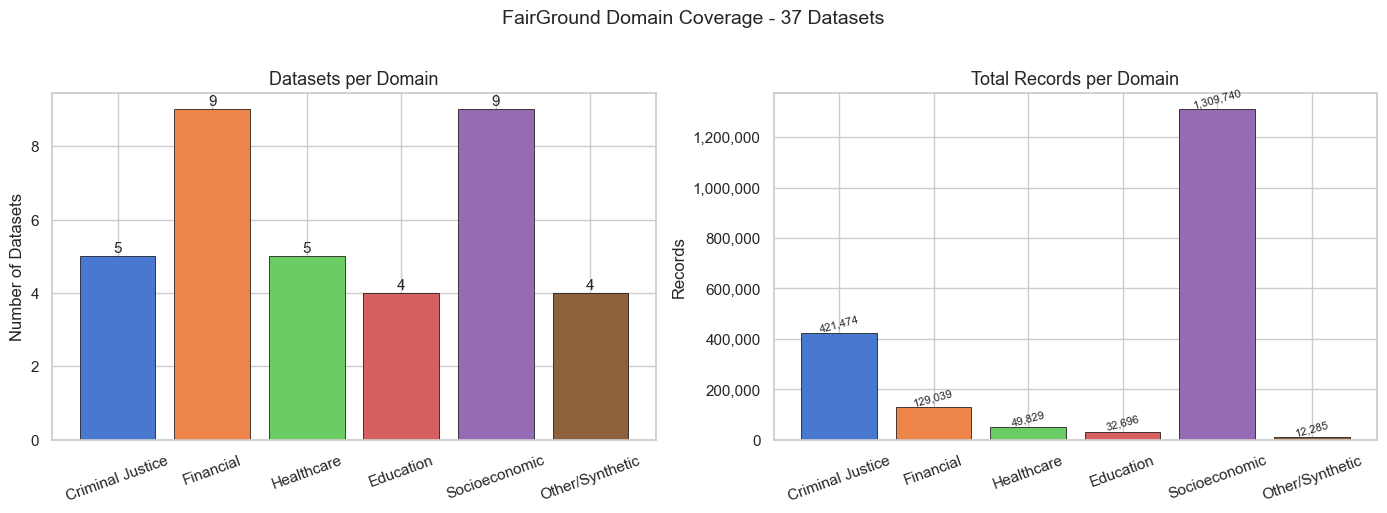

In [4]:
domain_stats = df.groupby('domain').agg(
    n_datasets=('dataset','count'),
    total_records=('n_samples','sum')
).reindex(DOMAIN_ORDER).reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colors = [DOMAIN_COLORS[d] for d in domain_stats['domain']]

ax1.bar(domain_stats['domain'], domain_stats['n_datasets'],
        color=colors, edgecolor='black', linewidth=0.5)
ax1.set_title('Datasets per Domain', fontsize=13)
ax1.set_ylabel('Number of Datasets')
ax1.tick_params(axis='x', rotation=20)
for i, val in enumerate(domain_stats['n_datasets']):
    ax1.text(i, val + 0.1, str(int(val)), ha='center', fontsize=11)

ax2.bar(domain_stats['domain'], domain_stats['total_records'],
        color=colors, edgecolor='black', linewidth=0.5)
ax2.set_title('Total Records per Domain', fontsize=13)
ax2.set_ylabel('Records')
ax2.tick_params(axis='x', rotation=20)
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{int(x):,}'))
for i, val in enumerate(domain_stats['total_records']):
    ax2.text(i, val + 5000, f'{int(val):,}', ha='center', fontsize=8, rotation=15)

plt.suptitle('FairGround Domain Coverage - 37 Datasets', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../figures/eda/fairground_domain_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Sensitive Attributes by Domain

Note: Sensitive attribute names are normalized to lowercase for visualization. Raw names vary across datasets (e.g. `age`, `Age`, `AGEP`) but represent the same attribute. This is a FairGround corpus characteristic, not a preprocessing choice.

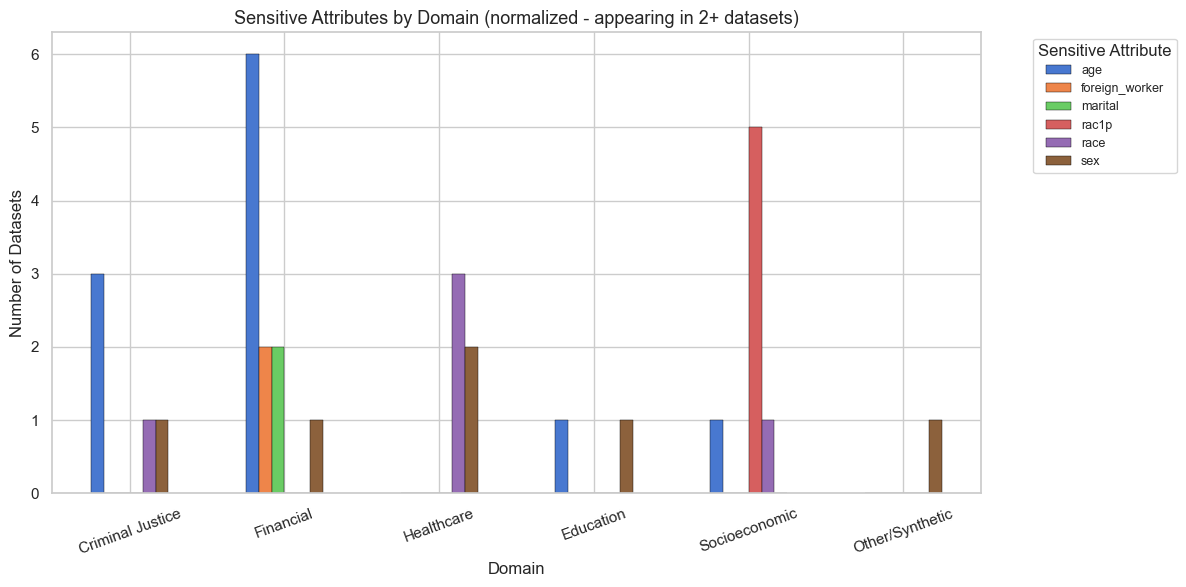

Sensitive attrs per domain (normalized):
  Criminal Justice: ['age', 'sex', 'race', 'race code cd']
  Financial: ['age', 'marital', 'foreign_worker', 'sex', '<= 25 years']
  Healthcare: ['race', 'sex']
  Education: ['racetxt', 'male', 'finance', 'sex', 'age']
  Socioeconomic: ['rac1p', 'race', 'racepctasian', 'pct12-21', 'age']
  Other/Synthetic: ['ethnicity', 's1', 'sex', 'sensible_feature']


In [5]:
# Normalize attr names to lowercase for consistent visualization
domain_attr_counts = {}
for domain in DOMAIN_ORDER:
    attrs = []
    for _, row in df[df['domain']==domain].iterrows():
        attrs.extend([a.lower().strip() for a in row['sensitive_cols']])
    domain_attr_counts[domain] = pd.Series(attrs).value_counts()

# Get all unique attrs across domains
all_norm_attrs = set()
for counts in domain_attr_counts.values():
    all_norm_attrs.update(counts.index)

# Build matrix, rows=domains, cols=attrs
matrix = pd.DataFrame(0, index=DOMAIN_ORDER, columns=sorted(all_norm_attrs))
for domain, counts in domain_attr_counts.items():
    for attr, count in counts.items():
        matrix.loc[domain, attr] = count

# Keep only attrs appearing in 2+ datasets, filter columns
cols_to_keep = matrix.columns[matrix.sum(axis=0) >= 2]
matrix_filtered = matrix[cols_to_keep]

fig, ax = plt.subplots(figsize=(12, 6))
matrix_filtered.plot(kind='bar', ax=ax,
            edgecolor='black', linewidth=0.3)
ax.set_title('Sensitive Attributes by Domain (normalized - appearing in 2+ datasets)', fontsize=13)
ax.set_xlabel('Domain')
ax.set_ylabel('Number of Datasets')
ax.tick_params(axis='x', rotation=20)
ax.legend(title='Sensitive Attribute', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('../figures/eda/fairground_sensitive_attrs_by_domain.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sensitive attrs per domain (normalized):')
for domain, counts in domain_attr_counts.items():
    print(f'  {domain}: {list(counts.index)}')

## 4. Sensitive Attribute Frequency, Top 10 Overall

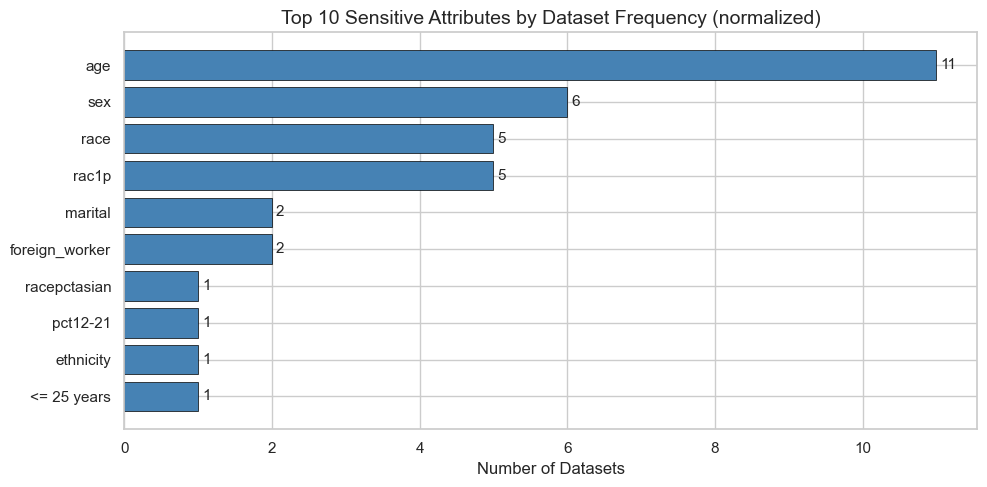

Note: age is most common (11 datasets), followed by rac1p/race (10 combined), sex (7 combined)


In [6]:
all_attrs_norm = []
for _, row in df.iterrows():
    all_attrs_norm.extend([a.lower().strip() for a in row['sensitive_cols']])
attr_counts = pd.Series(all_attrs_norm).value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(attr_counts.index[::-1], attr_counts.values[::-1],
        color='steelblue', edgecolor='black', linewidth=0.5)
ax.set_title('Top 10 Sensitive Attributes by Dataset Frequency (normalized)', fontsize=14)
ax.set_xlabel('Number of Datasets')
for i, (attr, val) in enumerate(zip(attr_counts.index[::-1], attr_counts.values[::-1])):
    ax.text(val + 0.05, i, str(val), va='center', fontsize=11)
plt.tight_layout()
plt.savefig('../figures/eda/fairground_sensitive_attributes.png', dpi=150, bbox_inches='tight')
plt.show()
print('Note: age is most common (11 datasets), followed by rac1p/race (10 combined), sex (7 combined)')

## 5. Label Balance Across Datasets

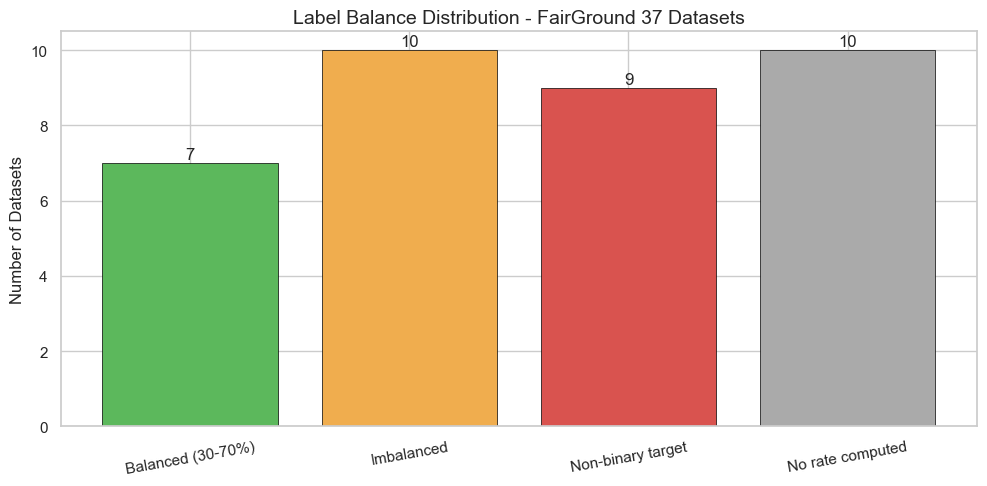

Only 17 of 37 datasets have interpretable binary rates
19 datasets have non-binary or undefined targets


In [7]:
balance_counts = df['balance'].value_counts()
balance_order = ['Balanced (30-70%)','Imbalanced','Non-binary target','No rate computed']
balance_counts = balance_counts.reindex(balance_order)

colors_map = {
    'Balanced (30-70%)': '#5cb85c',
    'Imbalanced': '#f0ad4e',
    'Non-binary target': '#d9534f',
    'No rate computed': '#aaaaaa'
}
bar_colors = [colors_map[b] for b in balance_order]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(balance_counts.index, balance_counts.values,
              color=bar_colors, edgecolor='black', linewidth=0.5)
ax.set_title('Label Balance Distribution - FairGround 37 Datasets', fontsize=14)
ax.set_ylabel('Number of Datasets')
ax.tick_params(axis='x', rotation=10)
for bar, val in zip(bars, balance_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            str(int(val)), ha='center', fontsize=12)
plt.tight_layout()
plt.savefig('../figures/eda/fairground_label_balance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Only {balance_counts["Balanced (30-70%)"] + balance_counts["Imbalanced"]} of 37 datasets have interpretable binary rates')
print(f'{balance_counts["Non-binary target"] + balance_counts["No rate computed"]} datasets have non-binary or undefined targets')

## 6. Feature Count Distribution

4 datasets have >200 features (arrhythmia: 279, MEPS panels: 1830-1940) and are excluded from the histogram. These high-dimensional datasets require dimensionality reduction before fairness evaluation.

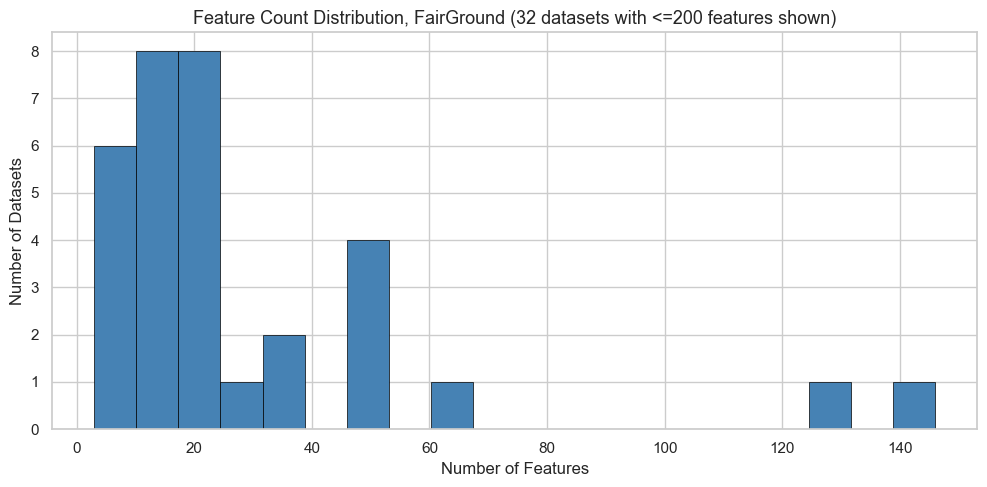

Excluded (>200 features):
  arrhythmia: 279 features
  meps_panel_19_fy2015: 1830 features
  meps_panel_20_fy2015: 1830 features
  meps_panel_21_fy2016: 1940 features
Median features (all 37): 20


In [8]:
df_plot = df[df['n_features'] <= 200].copy()
df_high = df[df['n_features'] > 200].copy()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(df_plot['n_features'], bins=20, color='steelblue',
        edgecolor='black', linewidth=0.5)
ax.set_title(
    f'Feature Count Distribution, FairGround ({len(df_plot)} datasets with <=200 features shown)',
    fontsize=13)
ax.set_xlabel('Number of Features')
ax.set_ylabel('Number of Datasets')
plt.tight_layout()
plt.savefig('../figures/eda/fairground_feature_counts.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Excluded (>200 features):')
for _, row in df_high.iterrows():
    print(f'  {row["dataset"]}: {row["n_features"]} features')
print(f'Median features (all 37): {df["n_features"].median():.0f}')

## 7. Records per Domain by Label Balance

Key insight for fairness evaluation: which domains have usable binary classification labels, and how does record volume relate to label quality across domains.

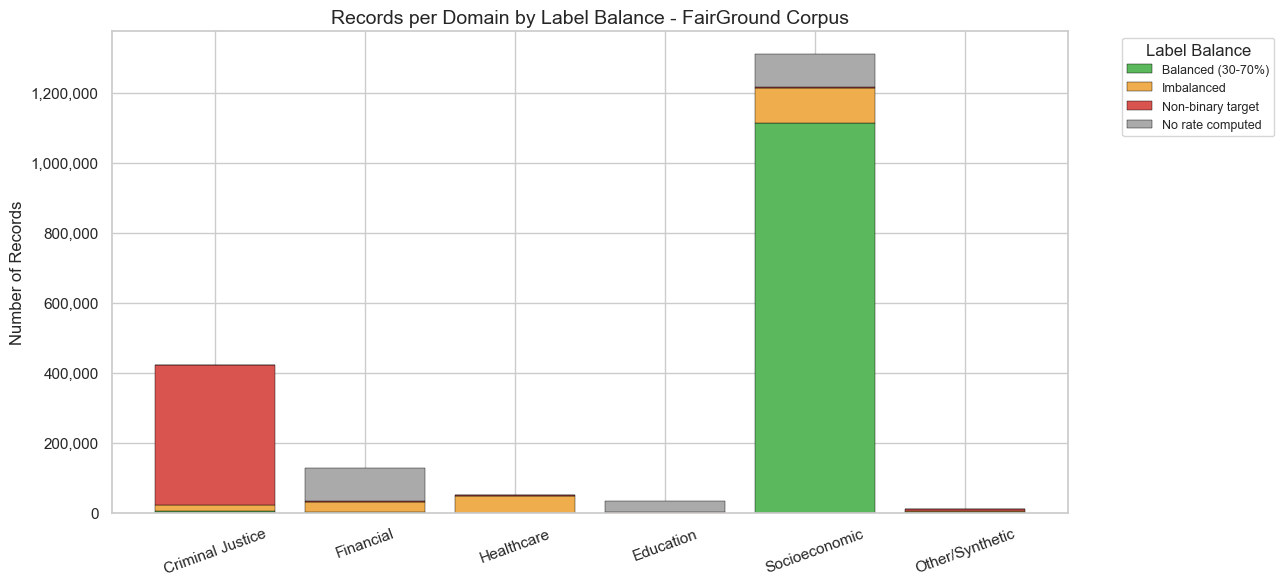

Key findings:
Socioeconomic: 1,214,546 usable binary records
Criminal Justice: 398,802 non-binary records (Chicago SSL dominates)
Healthcare: zero balanced records, all 49,378 records are imbalanced
Education: all 31,652 records have undefined labels


In [9]:
BALANCE_ORDER = ['Balanced (30-70%)','Imbalanced','Non-binary target','No rate computed']
BALANCE_COLORS = {
    'Balanced (30-70%)': '#5cb85c',
    'Imbalanced': '#f0ad4e',
    'Non-binary target': '#d9534f',
    'No rate computed': '#aaaaaa'
}

domain_balance = df.groupby(['domain','balance'])['n_samples'].sum().unstack(fill_value=0)
domain_balance = domain_balance.reindex(DOMAIN_ORDER)
domain_balance = domain_balance.reindex(columns=[c for c in BALANCE_ORDER if c in domain_balance.columns], fill_value=0)

fig, ax = plt.subplots(figsize=(13, 6))
bottom = pd.Series([0]*len(domain_balance), index=domain_balance.index)
for balance_cat in domain_balance.columns:
    color = BALANCE_COLORS.get(balance_cat, 'steelblue')
    ax.bar(domain_balance.index, domain_balance[balance_cat],
           bottom=bottom, label=balance_cat, color=color,
           edgecolor='black', linewidth=0.3)
    bottom = bottom + domain_balance[balance_cat]

ax.set_title('Records per Domain by Label Balance - FairGround Corpus', fontsize=14)
ax.set_ylabel('Number of Records')
ax.tick_params(axis='x', rotation=20)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{int(x):,}'))
ax.legend(title='Label Balance', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('../figures/eda/fairground_records_by_balance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Key findings:')
print(f'Socioeconomic: {domain_balance.loc["Socioeconomic","Balanced (30-70%)"] + domain_balance.loc["Socioeconomic","Imbalanced"]:,.0f} usable binary records')
print(f'Criminal Justice: {domain_balance.loc["Criminal Justice","Non-binary target"]:,.0f} non-binary records (Chicago SSL dominates)')
print(f'Healthcare: zero balanced records, all {domain_balance.loc["Healthcare","Imbalanced"]:,.0f} records are imbalanced')
print(f'Education: all {domain_balance.loc["Education","No rate computed"]:,.0f} records have undefined labels')

## 8. Top 10 Largest Datasets

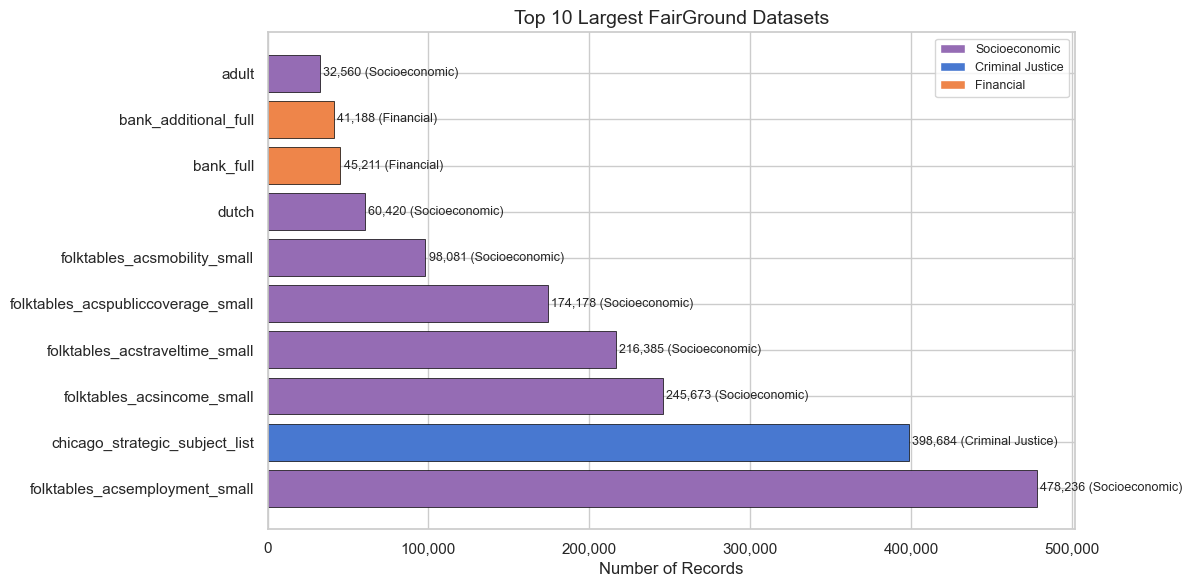

In [10]:
top10 = df.nlargest(10, 'n_samples').copy()

fig, ax = plt.subplots(figsize=(12, 6))
colors = [DOMAIN_COLORS[d] for d in top10['domain']]
bars = ax.barh(top10['dataset'], top10['n_samples'],
               color=colors, edgecolor='black', linewidth=0.5)
ax.set_title('Top 10 Largest FairGround Datasets', fontsize=14)
ax.set_xlabel('Number of Records')
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{int(x):,}'))
for bar, (_, row) in zip(bars, top10.iterrows()):
    ax.text(bar.get_width() + 2000, bar.get_y() + bar.get_height()/2,
            f'{row["n_samples"]:,} ({row["domain"]})', va='center', fontsize=9)
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=DOMAIN_COLORS[d], label=d)
                   for d in top10['domain'].unique()]
ax.legend(handles=legend_elements, fontsize=9)
plt.tight_layout()
plt.savefig('../figures/eda/fairground_top10_datasets.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Key Observations

**Corpus composition:** 37 datasets across 6 domains. Socioeconomic (9) and Financial (9) are most represented by dataset count. Socioeconomic dominates by record count, 1,309,740 records (67%) driven by folktables variants.

**Size imbalance:** Dataset sizes range from 118 (Ricci) to 478,236 (folktables_acsemployment_small). Top 5 datasets account for the majority of total records.

**Sensitive attribute inconsistency:** Age is the most common sensitive attribute (11 datasets) but naming is inconsistent across datasets (age, Age, AGEP). Race-related attributes appear in 10+ datasets under different names (RAC1P, race, Race, RACE, racetxt). This is a known FairGround corpus characteristic.

**Label quality:** Only 17 of 37 datasets have interpretable binary classification rates. 9 datasets have non-binary or continuous targets requiring special handling in Stage 2. 11 datasets have undefined rates.

**Domain label quality varies critically:** Socioeconomic has 1,214,546 usable binary records, the most reliable domain for fairness evaluation. Criminal Justice has 398,802 non-binary records (dominated by Chicago Strategic Subject List). Healthcare has zero balanced datasets, all 49,378 records are imbalanced. Education has 31,652 records with entirely undefined labels. These domain-level label quality differences directly affect Stage 2 fairness metric computation.

**Benchmark monoculture addressed:** FairGround's 37-dataset cross-domain coverage directly responds to Ding et al. (2021)'s critique of over-reliance on legacy datasets like Adult and COMPAS.